In [134]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully!


In [135]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 60
WINDOW_STRIDE_SAMPLES = 20
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [136]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
session_first_start_last_end AS (
    SELECT
        sei.session_task_id,
        MIN(sei.start_index) AS first_start_index,
        MAX(sei.next_end_index) AS last_end_index
    FROM start_end_indices sei
    GROUP BY sei.session_task_id
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        CASE WHEN smt.group_id is null THEN 'No Gesture' ELSE rtParent.title END AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' or smt.group_id is null THEN 0 ELSE 1 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
     JOIN session_first_start_last_end sfsle
      ON sd.session_task_id = sfsle.session_task_id
        AND sd.session_task_row_index BETWEEN sfsle.first_start_index AND sfsle.last_end_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [137]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [138]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [139]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [140]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
No Gesture                        225745
Tap and Hold                       11985
Pinch Swipe                        11370
Spread Swipe                        9049
Single Swipe                        6072
Two-Finger Opposite Double Tap      2929
Two-Finger Double Tap               2859
Double Tap                          2762
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1610
Single Tap                          1377
Name: count, dtype: int64

In [141]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [142]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    36375
6331fbd1-76bb-48d6-92a2-80a55a70d134    30507
696b4743-9d39-4fb1-8271-90e7d48652af    20977
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    43728
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    33659
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    35007
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    35425
fdd02af8-c764-43ba-8247-c612f85568b4    41799
dtype: int64

In [143]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel',
 'group_id']

In [144]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

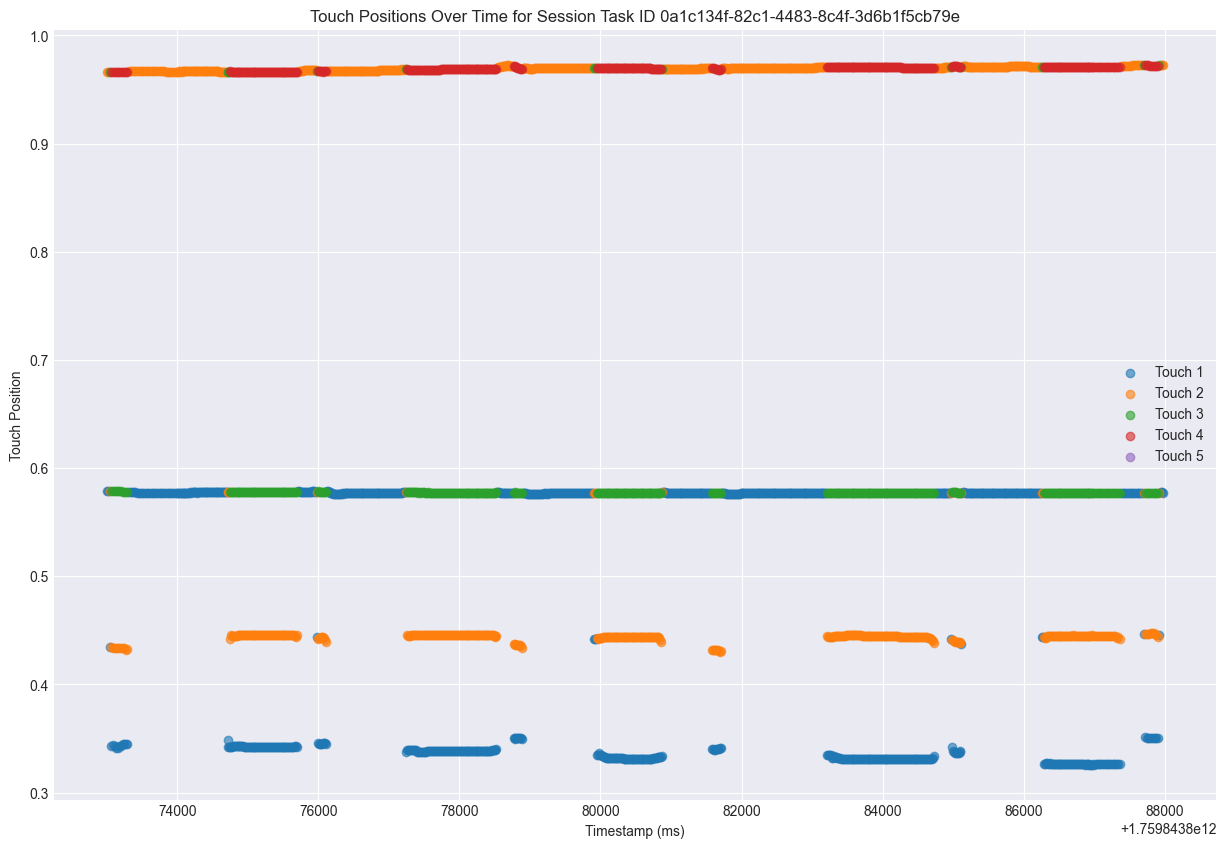

In [145]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_raw["session_task_id"].unique()[0]
session_df = df_raw[df_raw["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [146]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


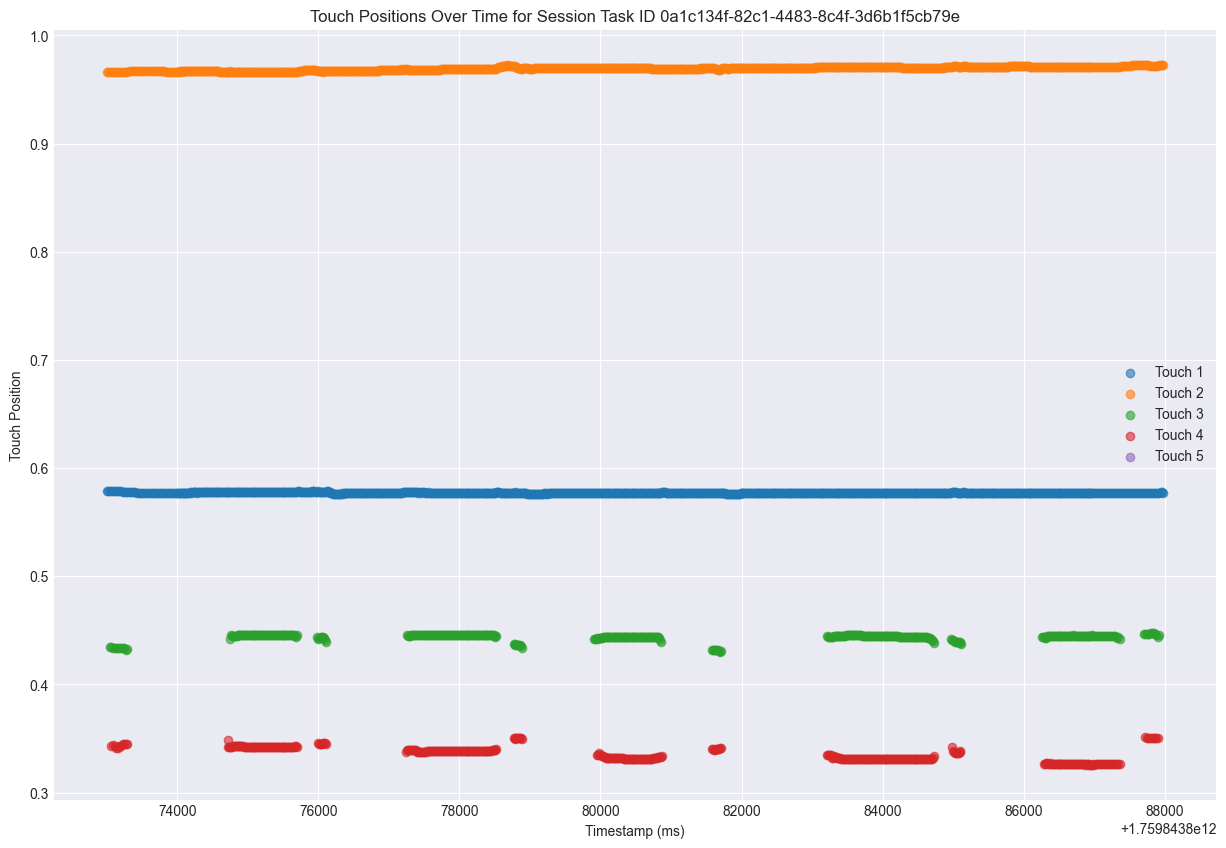

In [147]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_clean["session_task_id"].unique()[0]
session_df = df_clean[df_clean["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [148]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position         0
touch_1_pressure         0
touch_1_channel          0
touch_2_position         0
touch_2_pressure         0
touch_2_channel          0
touch_3_position         0
touch_3_pressure         0
touch_3_channel          0
touch_4_position         0
touch_4_pressure         0
touch_4_channel          0
touch_5_position         0
touch_5_pressure         0
touch_5_channel          0
group_id            199779
dtype: int64

In [149]:
# Print the LABEL_COLUMN counts
print(df_clean[LABEL_COLUMN].value_counts())

parent_gesture
No Gesture                        225745
Tap and Hold                       11985
Pinch Swipe                        11370
Spread Swipe                        9049
Single Swipe                        6072
Two-Finger Opposite Double Tap      2929
Two-Finger Double Tap               2859
Double Tap                          2762
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1610
Single Tap                          1377
Name: count, dtype: int64


In [150]:
# Add new features to the dataframe, for improved modeling
def create_feature_df(df_clean, smoothing_window=10):
    feature_df = df_clean.copy()
    additional_features = []

    def add_feature(name, values):
        feature_df[name] = values
        additional_features.append(name)

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    # Instant Features
    pressure_cols = [f"touch_{i+1}_pressure" for i in range(5)]
    add_feature("num_active_touches_instant", (feature_df[pressure_cols] > 0).sum(axis=1))
    # Distances for each finger in the rolling window to each other finger
    for (i, j) in combinations(range(1, 6), 2):
        pos_i = feature_df[f'touch_{i}_position']
        pos_j = feature_df[f'touch_{j}_position']
        p_i = feature_df[f"touch_{i}_pressure"]
        p_j = feature_df[f"touch_{j}_pressure"]

        # distance only when both fingers are active; else 0 (or np.nan if you prefer)
        dist_col = f"dist_{i}_{j}"
        dist = short_dist(pos_i, pos_j)
        both_active = (p_i > 0) & (p_j > 0)
        add_feature(dist_col, np.where(both_active, dist, 0.0))
    
    # Smoothed Features
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        pressure_col = f'touch_{touch_num}_pressure'
        channel_col = f'touch_{touch_num}_channel'

        add_feature(f'touch_{touch_num}_is_active', (feature_df[pressure_col] > 0).astype(int))
        
        add_feature(f'{position_col}_smoothed', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{pressure_col}_smoothed', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{channel_col}_smoothed', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).mean())
        
        add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0))
        add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0))
        add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0))
        
        add_feature(f'{position_col}_rollstd', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{pressure_col}_rollstd', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{channel_col}_rollstd', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))

    add_feature("num_active_touches_mean", feature_df["num_active_touches_instant"]
            .rolling(window=smoothing_window, min_periods=1)
            .mean())
    add_feature("num_active_touches_max", feature_df["num_active_touches_instant"]
            .rolling(window=smoothing_window, min_periods=1)
            .max())
    
    dist_cols = [c for c in feature_df.columns if c.startswith("dist_")]
    for col in dist_cols:
        add_feature(f"{col}_rollmean", feature_df[col]
            .rolling(window=smoothing_window, min_periods=1)
            .mean())
        add_feature(f"{col}_rollstd", feature_df[col]
            .rolling(window=smoothing_window, min_periods=1)
            .std()
            .fillna(0.0))

    return feature_df, additional_features

In [151]:
df, additional_columns = create_feature_df(df_clean)
feature_columns = SENSOR_COLUMNS + additional_columns

df = df.sort_values(
    by=["participant_id", "session_task_id", TIMESTAMP_COLUMN]
).reset_index(drop=True)

gesture_block = 0
prev_pid = None
prev_sid = None
prev_is_gesture = None
prev_label = None
blocks = []

for i, row in df.iterrows():
    pid = row["participant_id"]
    sid = row["session_task_id"]
    is_g = row["is_gesture"]
    lab = row[LABEL_COLUMN]

    # New block when:
    # - participant or session changes
    # - or gesture/background state changes
    # - or gesture label changes
    if (
        pid != prev_pid or
        sid != prev_sid or
        is_g != prev_is_gesture or
        lab != prev_label
    ):
        gesture_block += 1

    blocks.append(gesture_block)

    prev_pid = pid
    prev_sid = sid
    prev_is_gesture = is_g
    prev_label = lab

df["gesture_block"] = blocks

In [152]:
df.head()

,id,session_task_id,session_task_row_index,timestamp,timestamp_ms,button_pressed,motor_angle,gesture,parent_gesture,participant_id,is_gesture,group_id,estimated_timestamp,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,active_ids,num_active_touches_instant,dist_1_2,dist_1_3,dist_1_4,dist_1_5,dist_2_3,dist_2_4,dist_2_5,dist_3_4,dist_3_5,dist_4_5,touch_1_is_active,touch_1_position_smoothed,touch_1_pressure_smoothed,touch_1_channel_smoothed,touch_1_position_diff,touch_1_pressure_diff,touch_1_channel_diff,touch_1_position_rollstd,touch_1_pressure_rollstd,touch_1_channel_rollstd,touch_2_is_active,touch_2_position_smoothed,touch_2_pressure_smoothed,touch_2_channel_smoothed,touch_2_position_diff,touch_2_pressure_diff,touch_2_channel_diff,touch_2_position_rollstd,touch_2_pressure_rollstd,touch_2_channel_rollstd,touch_3_is_active,touch_3_position_smoothed,touch_3_pressure_smoothed,touch_3_channel_smoothed,touch_3_position_diff,touch_3_pressure_diff,touch_3_channel_diff,touch_3_position_rollstd,touch_3_pressure_rollstd,touch_3_channel_rollstd,touch_4_is_active,touch_4_position_smoothed,touch_4_pressure_smoothed,touch_4_channel_smoothed,touch_4_position_diff,touch_4_pressure_diff,touch_4_channel_diff,touch_4_position_rollstd,touch_4_pressure_rollstd,touch_4_channel_rollstd,touch_5_is_active,touch_5_position_smoothed,touch_5_pressure_smoothed,touch_5_channel_smoothed,touch_5_position_diff,touch_5_pressure_diff,touch_5_channel_diff,touch_5_position_rollstd,touch_5_pressure_rollstd,touch_5_channel_rollstd,num_active_touches_mean,num_active_touches_max,dist_1_2_rollmean,dist_1_2_rollstd,dist_1_3_rollmean,dist_1_3_rollstd,dist_1_4_rollmean,dist_1_4_rollstd,dist_1_5_rollmean,dist_1_5_rollstd,dist_2_3_rollmean,dist_2_3_rollstd,dist_2_4_rollmean,dist_2_4_rollstd,dist_2_5_rollmean,dist_2_5_rollstd,dist_3_4_rollmean,dist_3_4_rollstd,dist_3_5_rollmean,dist_3_5_rollstd,dist_4_5_rollmean,dist_4_5_rollstd,gesture_block
0,7ae236df-3b8a-46fe-be4b-fcabf2850ad1,0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e,639,2025-10-07 13:31:13,1759843873000,0,0.997409,Two-Finger Tap (4 Finger),Two-Finger Tap,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,03f74f16-3fea-4c43-9979-64c4636df12a,2025-10-07 13:31:13.000000000,0.578513,0.377551,0.400000,0.966209,0.572171,0.500000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,"[0, 1]",2,0.387696,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,1,0.578513,0.377551,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0.966209,0.572171,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,2.0,0.387696,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,1
1,139f6348-aacb-4142-b68b-768cbbb6f919,0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e,640,2025-10-07 13:31:13,1759843873022,0,0.997431,Two-Finger Tap (4 Finger),Two-Finger Tap,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,03f74f16-3fea-4c43-9979-64c4636df12a,2025-10-07 13:31:13.022727273,0.578533,0.375364,0.400000,0.966277,0.580334,0.500000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,"[0, 1]",2,0.387745,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,1,0.578523,0.376458,0.400000,0.000020,-0.002187,0.000000,0.000014,0.001546,0.000000,1,0.966243,0.576252,0.500000,0.000069,0.008163,0.000000,0.000049,0.005772,0.000000,0,0.000000,0.000000,0.000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,2.0,0.387720,0.000035,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000

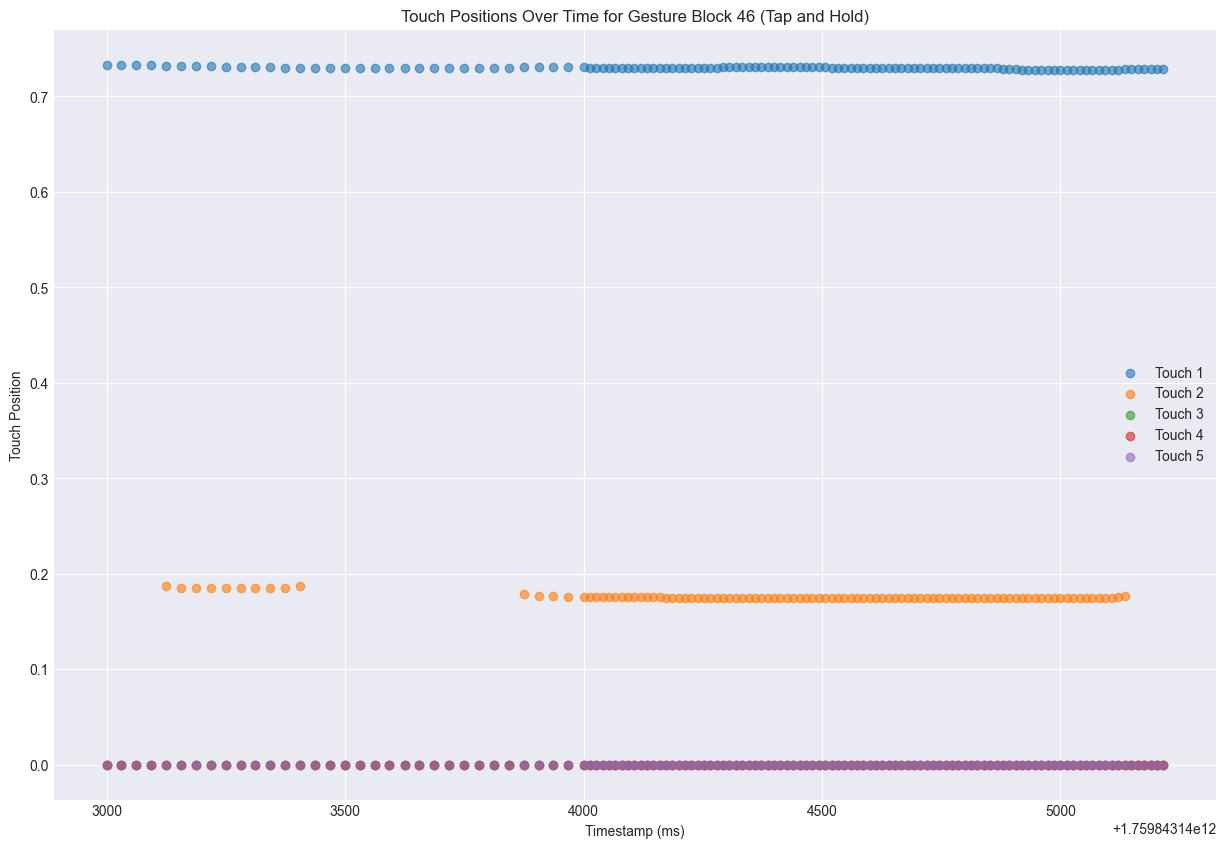

In [153]:
# draw a graph of the finger positions for the first gesture_block and title it with the parent_gesture

# get the index of the unique gesture block that is a "Tap and Hold" gesture
idx_tap_and_hold = np.where(df["gesture_block"].unique() == df[df[LABEL_COLUMN] == "Tap and Hold"]["gesture_block"].iloc[1])[0][0]

plt.figure(figsize=(15, 10))
first_gesture_block = df["gesture_block"].unique()[idx_tap_and_hold]
gesture_block_df = df[df["gesture_block"] == first_gesture_block]
for touch_num in range(1, 6):
    plt.scatter(
        gesture_block_df["timestamp_ms"], 
        gesture_block_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Gesture Block {first_gesture_block} ({gesture_block_df[LABEL_COLUMN].iloc[0]})")
plt.legend()
plt.show()

In [154]:
# Print unique "gesture" column counts
print(df["gesture"].value_counts())

gesture
Tap and Hold (3 Finger)                      22873
Tap and Hold (2 Finger)                      14352
Pinch Swipe (Rechts)                         13211
Lay On (2 Fingers)                           12997
Two-Finger Tap (3 Finger)                    12888
Knob Turn (3 Fingers)                        12172
Knob Turn (All Fingers)                      11944
Pinch Swipe (Links)                          11891
Lay On (3 Fingers)                           11869
Two-Finger Double Tap (4 Finger)             11017
Double Tap (4 Finger)                        10872
Spread Swipe (Rechts)                        10249
Two-Finger Double Tap (3 Finger)              9904
Single Swipe (All Air)                        9707
Two-Finger Opposite Double Tap (4 Finger)     9473
Spread Swipe (Links)                          9332
Two-Finger Opposite Tap (4 Finger)            9185
Single Swipe (3 Finger)                       9109
Two-Finger Opposite Tap (All Air)             8982
Two-Finger Tap (4 Finge

In [155]:
gesture_blocks = (
    df[df["is_gesture"] == 1]
    .groupby(["participant_id", "session_task_id", "gesture_block"])
)
print(f"Total gesture blocks (excluding 'No Gesture'): {len(gesture_blocks)}")

Total gesture blocks (excluding 'No Gesture'): 979


In [156]:
sequences = []   # list of arrays, each (T_i, D)
labels = []      # list of strings or ints

for (pid, sid, gb), gdf in gesture_blocks:
    # Extract feature matrix for this gesture
    X_seq = gdf[feature_columns].to_numpy(dtype="float32")  # shape (T_i, D)
    if len(X_seq) == 0:
        continue

    sequences.append(X_seq)
    labels.append(gdf[LABEL_COLUMN].iloc[0])  # all rows in block share the same label

In [157]:
# Print the number of sequences and unique labels
print(f"Extracted {len(sequences)} sequences with {len(set(labels))} unique labels.")
# Print the unique labels and their counts
label_counts = pd.Series(labels).value_counts()
print("Label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Extracted 979 sequences with 10 unique labels.
Label counts:
  Two-Finger Tap: 106
  Two-Finger Opposite Tap: 101
  Double Tap: 100
  Single Tap: 98
  Pinch Swipe: 97
  Single Swipe: 97
  Spread Swipe: 96
  Tap and Hold: 96
  Two-Finger Opposite Double Tap: 95
  Two-Finger Double Tap: 93


In [158]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_int = le.fit_transform(labels)           # shape (N,)
num_classes = len(le.classes_)
y = to_categorical(y_int, num_classes)     # shape (N, num_classes)


In [159]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(seq.shape[0] for seq in sequences)  # e.g. 400
D = sequences[0].shape[1]

X_padded = pad_sequences(
    sequences,
    maxlen=max_len,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0      # padding value
)  # shape: (N, max_len, D)
X = X_padded


In [160]:
unique_participants = df['participant_id'].unique()
print(f"Unique participants: {unique_participants}")

amount_of_participants = len(unique_participants)
amount_of_val_participants = max(1, int(0.2 * amount_of_participants))
amount_of_test_participants = max(1, int(0.2 * amount_of_participants))

val_participants = np.random.choice(unique_participants, size=amount_of_val_participants, replace=False)
remaining_participants = [p for p in unique_participants if p not in val_participants]
test_participants = np.random.choice(remaining_participants, size=amount_of_test_participants, replace=False)
train_participants = [p for p in remaining_participants if p not in test_participants]

print(f"Train participants: {train_participants}")
print(f"Validation participants: {val_participants}")
print(f"Test participants: {test_participants}")

Unique participants: ['5d52daf3-c962-4db6-a8f8-298a0bb01733'
 '6331fbd1-76bb-48d6-92a2-80a55a70d134'
 '696b4743-9d39-4fb1-8271-90e7d48652af'
 '6a1b56e6-47ce-43cb-96cb-713d055d8f6d'
 '707c3867-fe15-4b05-bf7b-fc5f3b501fb1'
 '754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0'
 'd3b39f0f-b799-4d69-b7a3-a663e5c7438f'
 'fdd02af8-c764-43ba-8247-c612f85568b4']
Train participants: ['5d52daf3-c962-4db6-a8f8-298a0bb01733', '696b4743-9d39-4fb1-8271-90e7d48652af', '6a1b56e6-47ce-43cb-96cb-713d055d8f6d', '707c3867-fe15-4b05-bf7b-fc5f3b501fb1', '754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0', 'fdd02af8-c764-43ba-8247-c612f85568b4']
Validation participants: ['6331fbd1-76bb-48d6-92a2-80a55a70d134']
Test participants: ['d3b39f0f-b799-4d69-b7a3-a663e5c7438f']


In [161]:
# Split participants into train, val, test sets
train_indices = df['participant_id'].isin(train_participants)
val_indices = df['participant_id'].isin(val_participants)
test_indices = df['participant_id'].isin(test_participants)

# Map each sequence back to its participant_id
sequence_participants = []
gesture_block_keys = list(gesture_blocks.groups.keys())
for (pid, sid, gb) in gesture_block_keys:
    sequence_participants.append(pid)
sequence_participants = np.array(sequence_participants)
# Now create boolean masks for sequences
train_seq_indices = np.isin(sequence_participants, train_participants)
val_seq_indices = np.isin(sequence_participants, val_participants)
test_seq_indices = np.isin(sequence_participants, test_participants)

X_train, y_train = X[train_seq_indices], y[train_seq_indices]
X_val, y_val = X[val_seq_indices], y[val_seq_indices]
X_test, y_test = X[test_seq_indices], y[test_seq_indices]
print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (731, 406, 100), (731, 10)
Validation set: (121, 406, 100), (121, 10)
Test set: (127, 406, 100), (127, 10)


In [162]:
# Per label, print the amount of samples in each split in one row
train_counts = pd.Series(np.argmax(y_train, axis=1)).value_counts().sort_index()
val_counts = pd.Series(np.argmax(y_val, axis=1)).value_counts().sort_index()
test_counts = pd.Series(np.argmax(y_test, axis=1)).value_counts().sort_index()
print("Label counts per split:")
for label_idx in range(num_classes):
    train_count = train_counts.get(label_idx, 0)
    val_count = val_counts.get(label_idx, 0)
    test_count = test_counts.get(label_idx, 0)
    label_name = le.classes_[label_idx]
    print(f"  {label_name}: Train={train_count}, Val={val_count}, Test={test_count}")

Label counts per split:
  Double Tap: Train=75, Val=12, Test=13
  Pinch Swipe: Train=73, Val=12, Test=12
  Single Swipe: Train=72, Val=12, Test=13
  Single Tap: Train=74, Val=12, Test=12
  Spread Swipe: Train=70, Val=12, Test=14
  Tap and Hold: Train=72, Val=11, Test=13
  Two-Finger Double Tap: Train=68, Val=13, Test=12
  Two-Finger Opposite Double Tap: Train=71, Val=12, Test=12
  Two-Finger Opposite Tap: Train=75, Val=12, Test=14
  Two-Finger Tap: Train=81, Val=13, Test=12


In [163]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

max_len = X_train.shape[1]
D = X_train.shape[2]
num_classes = y_train.shape[1]

model = Sequential()

# 1) Masking: ignore padded timesteps (value=0.0 from preprocessing)
model.add(Masking(mask_value=0.0, input_shape=(max_len, D)))

model.add(LSTM(128, return_sequences=True))

model.add(LSTM(64))

model.add(Dropout(0.3))

model.add(Dense(num_classes, activation="softmax"))

optimizer = Adam(learning_rate=5e-4)
model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_4 (Masking)             │ (None, 406, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 406, 128)       │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,306 (653.54 KB)

 Trainable params: 167,306 (653.54 KB)

 Non-trainable params: 0 (0.00 B)

In [164]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

batch_size = 16     # optimization knob: [16, 32, 64]
epochs = 100        # upper limit; early stopping will cut it earlier

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.2818 - loss: 2.1090 - val_accuracy: 0.3884 - val_loss: 1.7440
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.5622 - loss: 1.2892 - val_accuracy: 0.7107 - val_loss: 1.0999
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.7319 - loss: 0.8605 - val_accuracy: 0.7686 - val_loss: 0.8056
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 0.8222 - loss: 0.6049 - val_accuracy: 0.7769 - val_loss: 0.7825
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.8700 - loss: 0.4724 - val_accuracy: 0.8182 - val_loss: 0.7417
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.8878 - loss: 0.4187 - val_accuracy: 0.7603 - val_loss: 0.7325
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.9248 - loss: 0.3215 - val_accuracy: 0.7851 - val_loss: 0.6918
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.9083 - loss: 0.3498 - val_accu

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


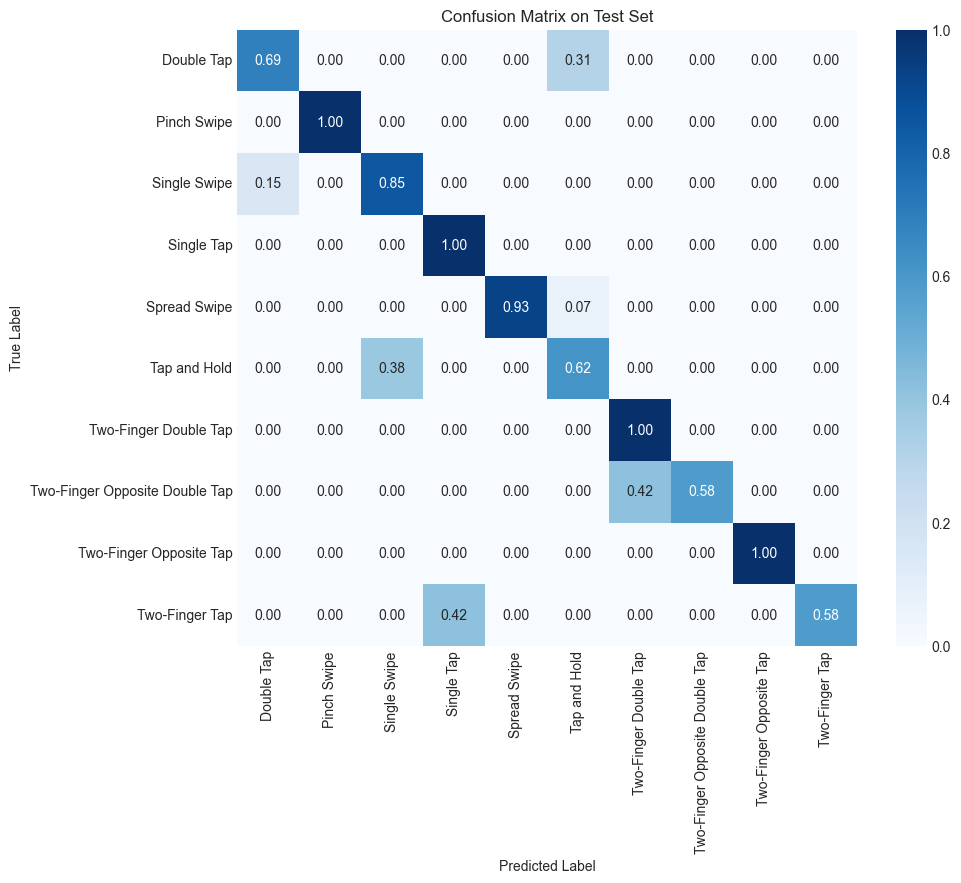

In [165]:
# Draw heatmap of confusion matrix for test set
from sklearn.metrics import confusion_matrix

y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

## Test with Szenarios

In [180]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
WHERE is_gesture = 1 and marker_label != 'No Gesture'
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,a0caf874-3fba-49a4-bd0e-36c370027f6b,002f4422-1f7b-4859-8f03-467e1f752000,335,2025-10-07 14:11:50,0,176.687363,0.395707,2063.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
1,b1971afb-c70b-45e2-970b-18512dd7beb4,002f4422-1f7b-4859-8f03-467e1f752000,336,2025-10-07 14:11:50,0,176.688904,0.394840,2067.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
2,7bbb27f4-3e45-467d-ba1e-a789024e1baf,002f4422-1f7b-4859-8f03-467e1f752000,337,2025-10-07 14:11:50,0,176.688126,0.394715,2065.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
3,86cfce39-cbc9-4917-86b6-fd2a80b1b3e3,002f4422-1f7b-4859-8f03-467e1f752000,338,2025-10-07 14:11:50,0,176.690048,0.394072,2079.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
4,c0cc105f-ec8c-4dd0-b8cd-4d1b61a9350a,002f4422-1f7b-4859-8f03-467e1f752000,339,2025-10-07 14:11:50,0,176.691193,0.393592,2081.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335


In [181]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [182]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


Session Task ID: 0542a515-ad14-49ec-84d7-c3b4e8b6ffe2


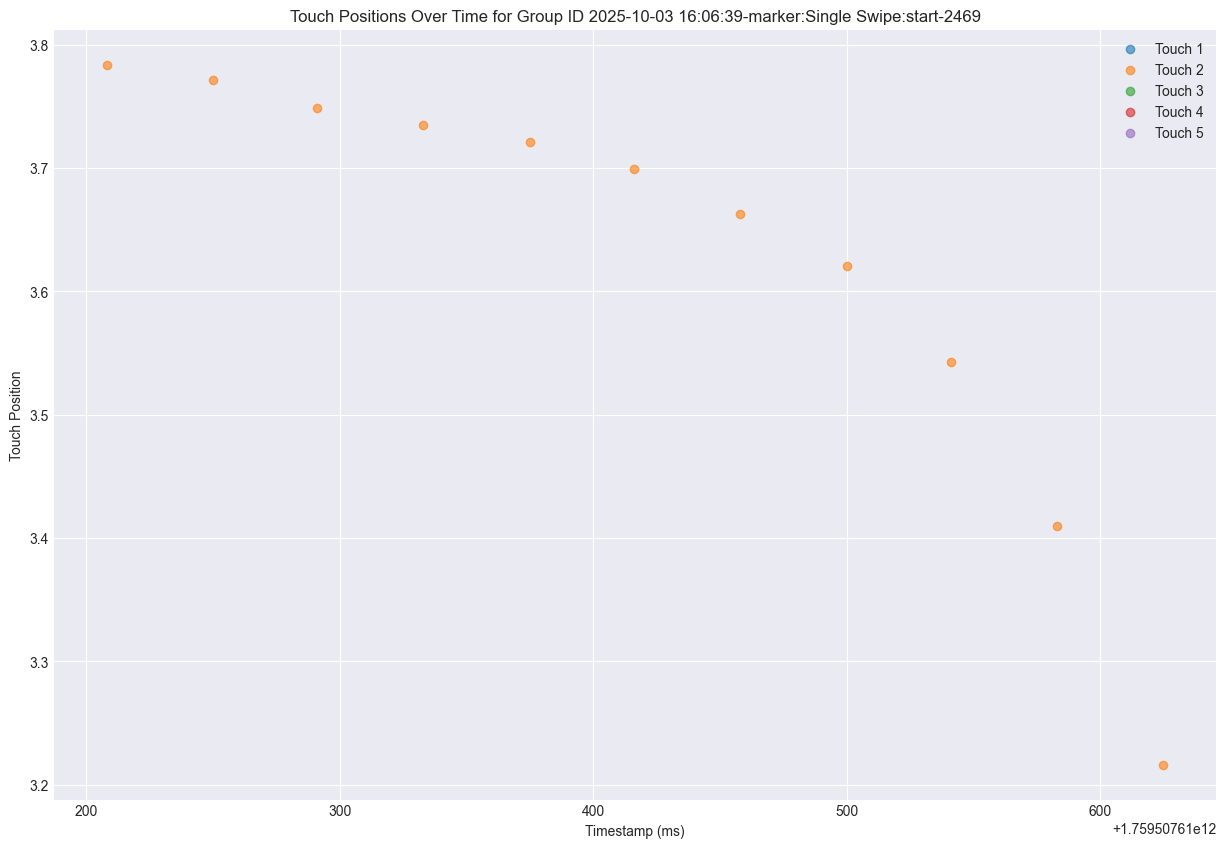

In [183]:
# Draw a graph of the first group_id in szenarien_df a scatter plot of touch positions over time
plt.figure(figsize=(15, 10))
first_group_id = szenarien_df["group_id"].unique()[14]
group_df = szenarien_df[szenarien_df["group_id"] == first_group_id]
# print the session_task_id
print(f"Session Task ID: {group_df['session_task_id'].iloc[0]}")
for touch_num in range(1, 6):
    plt.scatter(
        group_df["timestamp_ms"], 
        group_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Group ID {first_group_id}")
plt.legend()
plt.show()

In [184]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df[nan_columns].isna().sum()

touch_1_position    0
touch_1_pressure    0
touch_1_channel     0
touch_2_position    0
touch_2_pressure    0
touch_2_channel     0
touch_3_position    0
touch_3_pressure    0
touch_3_channel     0
touch_4_position    0
touch_4_pressure    0
touch_4_channel     0
touch_5_position    0
touch_5_pressure    0
touch_5_channel     0
group_id            0
dtype: int64

In [185]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

marker_label
Tap and Hold                      2479
Spread Swipe                      1723
Single Swipe                      1450
Pinch Swipe                        838
Two-Finger Opposite Double Tap     629
Two-Finger Tap                     551
Two-Finger Double Tap              484
Double Tap                         367
Two-Finger Opposite Tap            315
Single Tap                          16
Name: count, dtype: int64


In [186]:
# Print count of unique session_tasks
print(f"Unique session_task_ids in Szenarien data: {szenarien_df['session_task_id'].nunique()}")

Unique session_task_ids in Szenarien data: 20


In [187]:
# Make feature_df
szenarien_feature_df, szenarien_additional_columns = create_feature_df(szenarien_df)
szenarien_feature_columns = SENSOR_COLUMNS + szenarien_additional_columns

In [188]:
streams = {}        # session_task_id -> X_stream (T, D)
streams_labels = {} # session_task_id -> marker_label per frame (T,)

for sid, sdf in szenarien_feature_df.groupby("session_task_id"):
    X_stream = sdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    streams[sid] = X_stream
    streams_labels[sid] = y_stream

In [189]:
# Print number of streams
print(f"Extracted {len(streams)} streams from Szenarien data.")

Extracted 20 streams from Szenarien data.


In [190]:
max_len = 200
step_size = 10
threshold = 0.05             # gesture confidence; tune this

print(f"Using max_len={max_len}, threshold={threshold} for online prediction.")
touch_indices = [2, 5, 8, 11, 14]  # position columns for touch_1 to touch_5

# For debug purposes draw a graph of the finger positions for each window
def predict_stream_online(X_stream):
    did_print = 0
    T, D = X_stream.shape
    preds = []
    pred_times = []

    # Create a figure with 5 rows (one for each window we plan to print)
    # fig, axes = plt.subplots(5, 1, figsize=(15, 20))
    
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        window = X_stream[t_start:t_end]
        
        # ax = axes[did_print] # Select the subplot for this specific window
        
        # Draw all 5 fingers on THIS window's plot
        # for i, touch_num in enumerate(range(1, 6)):
            # col_idx = touch_indices[i]
            # x_vals = np.arange(t_start, t_end)
            # y_vals = window[:, col_idx]
            # 
            # ax.scatter(
                # x_vals, 
                # y_vals, 
                # label=f"Touch {touch_num}", 
                # alpha=0.6, 
                # s=12
            # )
        
        # ax.set_title(f"Window starting at index {t_start}")
        # ax.set_ylabel("Position")
        # ax.legend(loc="upper right", markerscale=2)
        # ax.grid(True, alpha=0.3)

        # --- Model Prediction Logic ---
        window_batch = window[np.newaxis, ...]
        proba = model.predict(window_batch, verbose=0)[0]
        
        # print all probabilities for debug with label
        # for cls_idx, class_label in enumerate(le.classes_):
            # ax.text(t_start, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]) * (cls_idx + 1), 
                    # f"{class_label}: {proba[cls_idx]:.2f}", fontsize=10, verticalalignment='bottom')

        cls_idx = np.argmax(proba)
        conf = proba[cls_idx]
        label = le.classes_[cls_idx] # if conf >= threshold else "No Gesture"
        
        # Add text info to the plot itself
        # ax.text(t_start, ax.get_ylim()[1], f"Pred: {label} ({conf:.2f})", 
                # fontsize=12, fontweight='bold', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

        preds.append(label)
        pred_times.append(t_start)

    #     did_print += 1
    #     if did_print >= 5:
    #         break

    # plt.tight_layout()
    # plt.show()
    return np.array(preds), np.array(pred_times)


Using max_len=200, threshold=0.05 for online prediction.


In [191]:
from sklearn.metrics import confusion_matrix, classification_report

all_true = []
all_pred = []

# print streams keys
did_it = 0
for sid, X_stream in streams.items():
    did_it += 1
    y_stream = streams_labels[sid] 
    preds, pred_times = predict_stream_online(X_stream)

    # Use center index for each window
    centers = pred_times + max_len // 2

    for p_label, c in zip(preds, centers):
        if c >= len(y_stream):
            continue
        all_pred.append(p_label)
        all_true.append(y_stream[c] if y_stream[c] is not None else "No Gesture")

    # Print y_stream for those that are not none
    # print(f"True labels for stream {sid}:")
    # for i in range(len(y_stream)):
    #     if y_stream[i] is not None:
    #         print(f"  Index {i}: {y_stream[i]}")

    # if did_it >= 1:
    #     break


In [192]:
# Print unique all_true and all_pred labels
all_true = np.array(all_true)
all_pred = np.array(all_pred)
# Replace None with "No Gesture" in all_true
all_true = np.array([label if label is not None and label != 'No Gesture' else "No Gesture" for label in all_true])
unique_true_labels = np.unique(all_true)
unique_pred_labels = np.unique(all_pred)
print(f"Unique true labels: {unique_true_labels}")
print(f"Unique predicted labels: {unique_pred_labels}")

Unique true labels: ['Double Tap' 'Pinch Swipe' 'Single Swipe' 'Single Tap' 'Spread Swipe'
 'Tap and Hold' 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']
Unique predicted labels: ['Double Tap' 'Single Swipe' 'Single Tap' 'Spread Swipe' 'Tap and Hold'
 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']


                                precision    recall  f1-score   support

                    Double Tap       0.05      0.07      0.06        15
                   Pinch Swipe       0.00      0.00      0.00        65
                  Single Swipe       0.21      0.04      0.07        92
                    Single Tap       0.00      0.00      0.00         1
                  Spread Swipe       0.00      0.00      0.00       102
                  Tap and Hold       0.20      0.10      0.13       178
         Two-Finger Double Tap       0.00      0.00      0.00         7
Two-Finger Opposite Double Tap       0.00      0.00      0.00        28
       Two-Finger Opposite Tap       0.05      0.18      0.07        28
                Two-Finger Tap       0.03      0.20      0.05        10

                      accuracy                           0.06       526
                     macro avg       0.05      0.06      0.04       526
                  weighted avg       0.11      0.06      0.06 

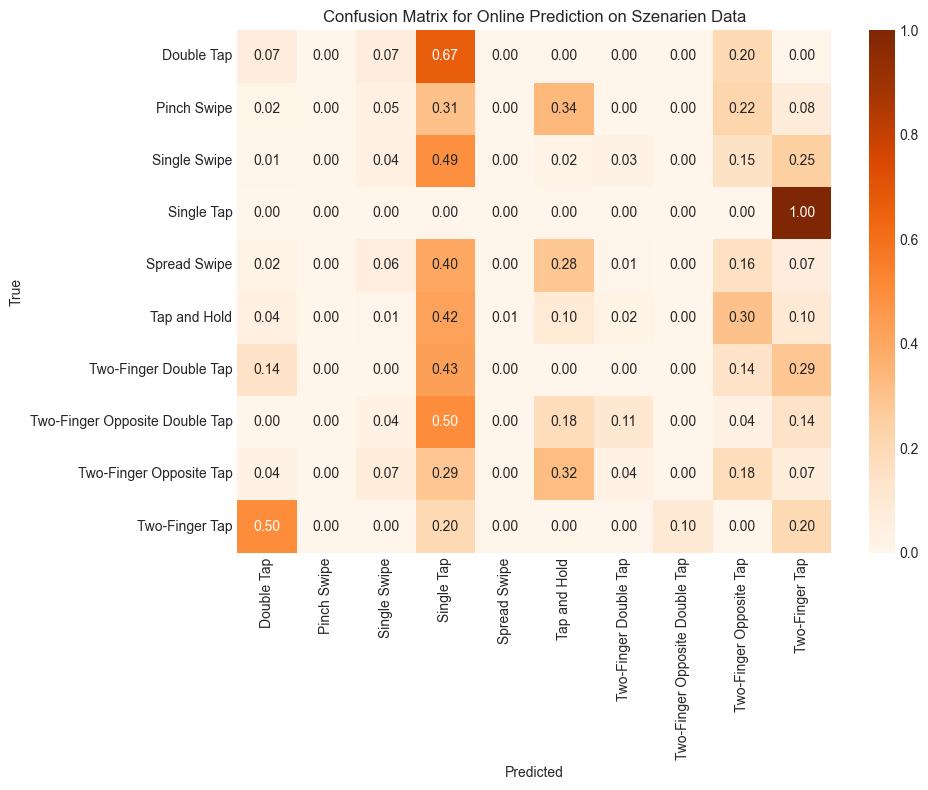

In [193]:
# Optionally restrict to known classes
# map string labels -> indices with same LabelEncoder if classes match
y_true_int = le.transform(all_true)           # if marker labels use same names
y_pred_int = le.transform(all_pred)

cm = confusion_matrix(y_true_int, y_pred_int)
print(classification_report(y_true_int, y_pred_int, target_names=le.classes_))

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Oranges"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Online Prediction on Szenarien Data")
plt.tight_layout()
plt.show()


In [194]:
# Test with szenarios, but give a whole marker_label group at once to check if the classification would work with the correct windowing strategy

# Put all group_ids in windows
windows = []
window_lables = []
for gid, gdf in szenarien_feature_df.groupby("group_id"):
    # ignore if the marker_label is "No Gesture" or None
    if gdf["marker_label"].iloc[0] is None or gdf["marker_label"].iloc[0] == "No Gesture":
        continue
    X_window = gdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    windows.append(X_window)
    window_lables.append(gdf["marker_label"].iloc[0])

print(f"Created {len(windows)} windows from Szenarien data for group_id prediction.")

Created 147 windows from Szenarien data for group_id prediction.


In [195]:
# Print min and max length of windows
window_lengths = [w.shape[0] for w in windows]
print(f"Window lengths: min={min(window_lengths)}, max={max(window_lengths)}")
# Print count of labels
label_counts = pd.Series(window_lables).value_counts()
print("Window label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Window lengths: min=12, max=333
Window label counts:
  Two-Finger Tap: 28
  Single Swipe: 25
  Spread Swipe: 18
  Two-Finger Opposite Double Tap: 17
  Two-Finger Double Tap: 14
  Tap and Hold: 13
  Two-Finger Opposite Tap: 13
  Double Tap: 11
  Pinch Swipe: 7
  Single Tap: 1


In [196]:
# Predict each window
all_window_true = []
all_window_pred = []

for X_window, true_label in zip(windows, window_lables):
    T, D = X_window.shape
    if T < max_len:
        # Pad if too short
        X_padded = np.pad(
            X_window,
            ((0, max_len - T), (0, 0)),
            mode="constant",
            constant_values=-1.0
        )
    else:
        # Truncate if too long
        X_padded = X_window[:max_len, :]

    X_batch = X_padded[np.newaxis, ...]  # (1, max_len, D)
    proba = model.predict(X_batch, verbose=0)[0]
    
    cls_idx = np.argmax(proba)
    conf = proba[cls_idx]
    pred_label = le.classes_[cls_idx] if conf >= threshold else "No Gesture"

    all_window_true.append(true_label)
    all_window_pred.append(pred_label)
# Print unique all_window_true and all_window_pred labels
all_window_true = np.array(all_window_true)
all_window_pred = np.array(all_window_pred)
unique_window_true_labels = np.unique(all_window_true)
unique_window_pred_labels = np.unique(all_window_pred)
print(f"Unique true window labels: {unique_window_true_labels}")
print(f"Unique predicted window labels: {unique_window_pred_labels}")

Unique true window labels: ['Double Tap' 'Pinch Swipe' 'Single Swipe' 'Single Tap' 'Spread Swipe'
 'Tap and Hold' 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']
Unique predicted window labels: ['Pinch Swipe' 'Single Swipe' 'Single Tap' 'Spread Swipe' 'Tap and Hold'
 'Two-Finger Double Tap' 'Two-Finger Opposite Tap']


                                precision    recall  f1-score   support

                    Double Tap       0.00      0.00      0.00        11
                   Pinch Swipe       0.02      0.29      0.03         7
                  Single Swipe       0.28      0.28      0.28        25
                    Single Tap       0.00      0.00      0.00         1
                  Spread Swipe       0.50      0.06      0.10        18
                  Tap and Hold       0.67      0.15      0.25        13
         Two-Finger Double Tap       0.00      0.00      0.00        14
Two-Finger Opposite Double Tap       0.00      0.00      0.00        17
       Two-Finger Opposite Tap       0.00      0.00      0.00        13
                Two-Finger Tap       0.00      0.00      0.00        28

                      accuracy                           0.08       147
                     macro avg       0.15      0.08      0.07       147
                  weighted avg       0.17      0.08      0.08 

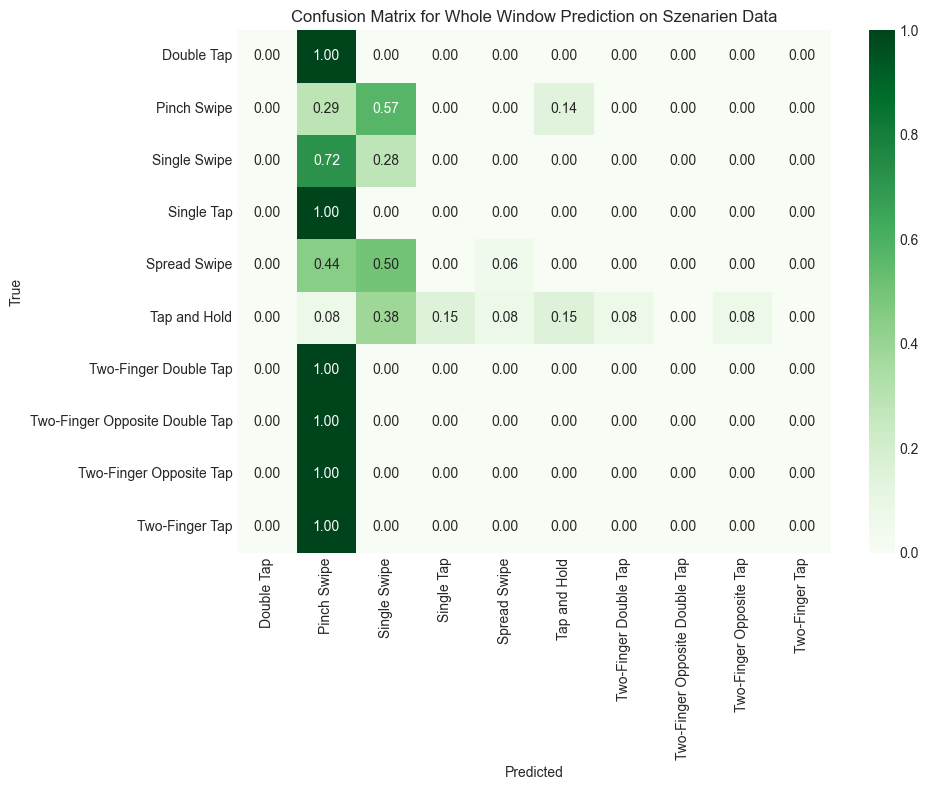

In [197]:
# Print confusion matrix and classification report for window predictions
y_window_true_int = le.transform(all_window_true)           # if marker labels use same names
y_window_pred_int = le.transform(all_window_pred)
cm_window = confusion_matrix(y_window_true_int, y_window_pred_int)
print(classification_report(y_window_true_int, y_window_pred_int, target_names=le.classes_))
cm_window_norm = cm_window.astype('float') / cm_window.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_window_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Greens"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Whole Window Prediction on Szenarien Data")
plt.tight_layout()
plt.show()